# Modeling


## Setup


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc
import json
import sys
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    ParameterSampler,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("../data")
FEATURE_PATH = DATA_DIR / "application_features.parquet"
SPLIT_PATH = DATA_DIR / "split_assignments.parquet"

features = pd.read_parquet(FEATURE_PATH)
split_assignments = pd.read_parquet(SPLIT_PATH)
feature_dictionary = json.loads((DATA_DIR / "feature_dictionary.json").read_text())

data = features.merge(
    split_assignments[["SK_ID_CURR", "SPLIT"]],
    on="SK_ID_CURR",
    how="inner",
    validate="one_to_one",
)
print(f"Feature table: {features.shape}")
print(data["SPLIT"].value_counts())

Feature table: (307511, 198)
SPLIT
train    246008
test      61503
Name: count, dtype: int64


## Fixed train, development, validation and holdout sets

In [2]:
target_col = "TARGET"
identifier_col = "SK_ID_CURR"
model_drop_features = feature_dictionary.get("model_drop_features", [])
excluded_cols = [target_col, identifier_col, "SPLIT"] + [
    col for col in model_drop_features if col in data.columns
]

train_data = data[data["SPLIT"].eq("train")].copy()
holdout_data = data[data["SPLIT"].eq("test")].copy()

X_train = train_data.drop(columns=excluded_cols)
y_train = train_data[target_col].astype("int8")
X_holdout = holdout_data.drop(columns=excluded_cols)
y_holdout = holdout_data[target_col].astype("int8")

if "CUSTOMER_SEGMENT" in X_train.columns:
    X_train["CUSTOMER_SEGMENT"] = X_train["CUSTOMER_SEGMENT"].astype("string")
    X_holdout["CUSTOMER_SEGMENT"] = X_holdout["CUSTOMER_SEGMENT"].astype("string")

X_dev, X_val, y_dev, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train,
)

split_summary = pd.DataFrame({
    "rows": [len(X_dev), len(X_val), len(X_holdout)],
    "default_rate_pct": [
        y_dev.mean() * 100,
        y_val.mean() * 100,
        y_holdout.mean() * 100,
    ],
}, index=["development", "validation", "holdout"])
display(split_summary)
print(f"Excluded from decisioning: {model_drop_features}")

,rows,default_rate_pct
development,196806,8.072925
validation,49202,8.072843
holdout,61503,8.072777


Excluded from decisioning: ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'ORGANIZATION_TYPE', 'CUSTOMER_SEGMENT_NAME']


## Preprocessing pipelines


In [3]:
numeric_features = X_dev.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_dev.select_dtypes(exclude=np.number).columns.tolist()

linear_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
linear_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
linear_preprocessor = ColumnTransformer([
    ("numeric", linear_numeric, numeric_features),
    ("categorical", linear_categorical, categorical_features),
], remainder="drop", sparse_threshold=0.30, verbose_feature_names_out=False)

tree_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
tree_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
tree_preprocessor = ColumnTransformer([
    ("numeric", tree_numeric, numeric_features),
    ("categorical", tree_categorical, categorical_features),
], remainder="drop", sparse_threshold=0.30, verbose_feature_names_out=False)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 177
Categorical features: 14


## Metrics


In [4]:
def optimal_f1_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if len(thresholds) == 0:
        return 0.5
    numerator = 2 * precision[:-1] * recall[:-1]
    denominator = precision[:-1] + recall[:-1]
    f1_values = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )
    return float(thresholds[int(np.nanargmax(f1_values))])


def evaluate_probabilities(y_true, probabilities, threshold=None):
    if threshold is None:
        threshold = optimal_f1_threshold(y_true, probabilities)
    predictions = (probabilities >= threshold).astype("int8")
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    auroc = roc_auc_score(y_true, probabilities)
    return {
        "AUROC": auroc,
        "Gini": 2 * auroc - 1,
        "KS": float(np.max(tpr - fpr)),
        "AUPRC": average_precision_score(y_true, probabilities),
        "F1": f1_score(y_true, predictions),
        "Brier": brier_score_loss(y_true, probabilities),
        "threshold": float(threshold),
    }

## Baseline model comparison


In [5]:
candidate_pipelines = {
    "Dummy": Pipeline([
        ("model", DummyClassifier(strategy="prior", random_state=42)),
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessor", clone(linear_preprocessor)),
        ("model", LogisticRegression(
            C=0.10,
            class_weight="balanced",
            max_iter=1000,
            random_state=42,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", clone(tree_preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced_subsample",
            random_state=42,
        )),
    ]),
    "Gradient Boost": Pipeline([
        ("preprocessor", clone(tree_preprocessor)),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=125,
            max_depth=6,
            class_weight="balanced",
            scoring="roc_auc",
            random_state=42,
        )),
    ])
}

comparison_rows = []
validation_probabilities = {}

for name, pipeline in candidate_pipelines.items():
    pipeline_template = clone(pipeline)
    started = time.perf_counter()
    pipeline.fit(X_dev, y_dev)
    probabilities = pipeline.predict_proba(X_val)[:, 1]
    metrics = evaluate_probabilities(y_val, probabilities)
    metrics["model"] = name
    metrics["fit_seconds"] = time.perf_counter() - started
    comparison_rows.append(metrics)
    validation_probabilities[name] = probabilities
    candidate_pipelines[name] = pipeline_template
    del pipeline
    gc.collect()

comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .sort_values("AUROC", ascending=False)
)
display(comparison)

,AUROC,Gini,KS,AUPRC,F1,Brier,threshold,fit_seconds
model,,,,,,,,
Gradient Boost,0.755732,0.511464,0.381823,0.243960,0.304130,0.191199,0.672718,15.153016
Logistic Regression,0.747449,0.494897,0.365922,0.224878,0.296473,0.201623,0.644096,9.441438
Random Forest,0.737202,0.474403,0.351170,0.216613,0.285689,0.182704,0.596314,83.910772
Dummy,0.500000,0.000000,0.000000,0.080728,0.149396,0.074211,0.080729,0.020899


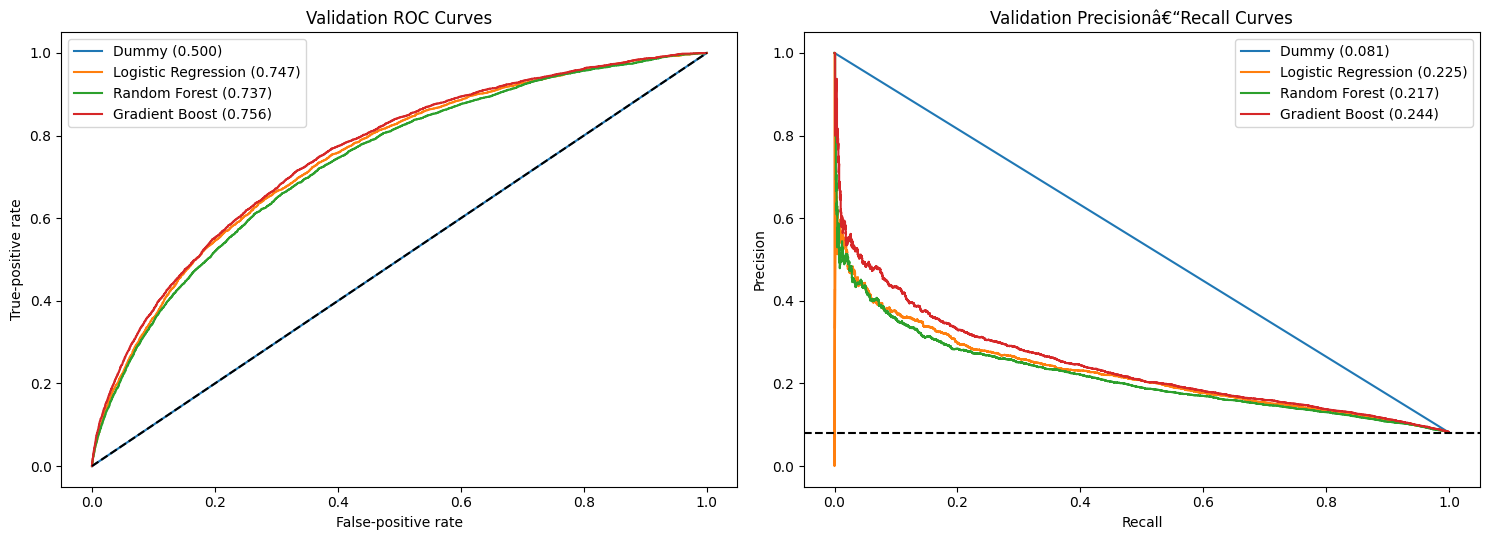

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for name, probabilities in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, probabilities)
    precision, recall, _ = precision_recall_curve(y_val, probabilities)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_val, probabilities):.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({average_precision_score(y_val, probabilities):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[0].set_title("Validation ROC Curves")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].legend()

axes[1].axhline(y_val.mean(), linestyle="--", color="black")
axes[1].set_title("Validation Precisionâ€“Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

## Hyperparameter tuning


In [7]:
selected_model_name = (
    comparison
    .drop(index="Dummy")["AUROC"]
    .idxmax()
)

hgb_search_space = {
    "model__learning_rate": [0.01, 0.025, 0.05, 0.075, 0.1],
    "model__max_iter": [100, 125, 150, 200],
    "model__max_depth": [3, 5, 7, 9],
}

random_forest_search_space = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_leaf": [1, 2, 5, 10],
}

logistic_search_space = {
    "model__C": np.logspace(-3, 1, 50),
    "model__max_iter": [500, 1000, 2000],
}

search_spaces = {
    "Gradient Boost": hgb_search_space,
    "Random Forest": random_forest_search_space,
    "Logistic Regression": logistic_search_space
}

search_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

checkpoint_path = Path("../models/search_checkpoint.json")
checkpoint = None

if checkpoint_path.exists():
    checkpoint = json.loads(checkpoint_path.read_text())

checkpoint_is_valid = (
    checkpoint is not None
    and checkpoint.get("selected_model") == selected_model_name
    and selected_model_name in candidate_pipelines
)

if checkpoint_is_valid:
    cached_estimator = clone(
        candidate_pipelines[selected_model_name]
    ).set_params(**checkpoint["best_parameters"])

    cached_estimator.fit(X_dev, y_dev)

    search = SimpleNamespace(
        best_estimator_=cached_estimator,
        best_params_=checkpoint["best_parameters"],
        best_score_=checkpoint["best_score"],
    )
else:
    search = RandomizedSearchCV(
        estimator=clone(candidate_pipelines[selected_model_name]),
        param_distributions=search_spaces[selected_model_name],
        n_iter=50,
        scoring="roc_auc",
        cv=search_cv,
        refit=True,
        n_jobs=1,
        random_state=42,
        verbose=0,
        return_train_score=False,
    )

    search.fit(X_dev, y_dev)

    checkpoint_path.write_text(
        json.dumps(
            {
                "selected_model": selected_model_name,
                "best_score": search.best_score_,
                "best_parameters": search.best_params_,
            },
            indent=2,
        )
    )

print(f"Selected model: {selected_model_name}")
print(f"Best CV AUROC: {search.best_score_:.4f}")

display(
    pd.Series(
        search.best_params_,
        name="value",
    ).to_frame()
)

Selected model: Gradient Boost
Best CV AUROC: 0.7616


,value
model__max_iter,200.00
model__max_depth,9.00
model__learning_rate,0.05


## Customer segment evaluation


In [23]:
segment_feature = "CUSTOMER_SEGMENT"
segment_available = all(
    segment_feature in frame.columns
    for frame in [X_dev, X_val, train_data, holdout_data]
)

with_segment_pipeline = search.best_estimator_
with_segment_probabilities = with_segment_pipeline.predict_proba(X_val)[:, 1]
with_segment_auc = roc_auc_score(y_val, with_segment_probabilities)

cluster_uplift_report = pd.DataFrame(columns=[
    "configuration",
    "validation_AUROC",
    "delta_vs_without",
])

if segment_available:
    X_dev_without_segment = X_dev.drop(columns=segment_feature)
    X_val_without_segment = X_val.drop(columns=segment_feature)

    ablation_numeric = X_dev_without_segment.select_dtypes(include=np.number).columns.tolist()
    ablation_categorical = X_dev_without_segment.select_dtypes(exclude=np.number).columns.tolist()

    ablation_numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if selected_model_name == "Logistic Regression":
        ablation_numeric_steps.append(("scaler", StandardScaler()))

    ablation_preprocessor = ColumnTransformer([
        ("numeric", Pipeline(ablation_numeric_steps), ablation_numeric),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), ablation_categorical),
    ], remainder="drop", sparse_threshold=0.30, verbose_feature_names_out=False)

    without_segment_pipeline = Pipeline([
        ("preprocessor", ablation_preprocessor),
        ("model", clone(search.best_estimator_.named_steps["model"])),
    ])
    without_segment_pipeline.fit(X_dev_without_segment, y_dev)
    without_segment_probabilities = without_segment_pipeline.predict_proba(X_val_without_segment)[:, 1]
    without_segment_auc = roc_auc_score(y_val, without_segment_probabilities)

    cluster_uplift_report = pd.DataFrame({
        "configuration": ["With customer segment", "Without customer segment"],
        "validation_AUROC": [with_segment_auc, without_segment_auc],
    })
    cluster_uplift_report["delta_vs_without"] = (
        cluster_uplift_report["validation_AUROC"] - without_segment_auc
    )

    use_customer_segment = with_segment_auc > without_segment_auc
    model_drop_features = [
        feature for feature in model_drop_features
        if feature != segment_feature
    ]
else:
    use_customer_segment = False

if use_customer_segment:
    selected_estimator_template = clone(with_segment_pipeline)
    selected_feature_names = X_dev.columns.tolist()
    X_train_model = train_data.loc[:, selected_feature_names].copy()
    X_holdout_model = holdout_data.loc[:, selected_feature_names].copy()
    tuned_validation_probabilities = with_segment_probabilities
    print("Customer segment retained because it improved validation AUROC.")
else:
    if segment_available:
        selected_estimator_template = clone(without_segment_pipeline)
        tuned_validation_probabilities = without_segment_probabilities
        model_drop_features = sorted(set(model_drop_features + [segment_feature]))
        print("Customer segment excluded because it did not improve validation AUROC.")
    else:
        selected_estimator_template = clone(with_segment_pipeline)
        tuned_validation_probabilities = with_segment_probabilities
        print("Customer segment was not available for evaluation.")

    selected_feature_names = [
        feature for feature in X_dev.columns
        if feature != segment_feature
    ]
    X_train_model = train_data.loc[:, selected_feature_names].copy()
    X_holdout_model = holdout_data.loc[:, selected_feature_names].copy()

if segment_feature in X_train_model.columns:
    X_train_model[segment_feature] = X_train_model[segment_feature].astype("string")
    X_holdout_model[segment_feature] = X_holdout_model[segment_feature].astype("string")

assert X_train_model.columns.equals(X_holdout_model.columns)

decision_threshold = optimal_f1_threshold(y_val, tuned_validation_probabilities)
tuned_validation_metrics = evaluate_probabilities(
    y_val,
    tuned_validation_probabilities,
    threshold=decision_threshold,
)

if not cluster_uplift_report.empty:
    display(cluster_uplift_report.style.format({
        "validation_AUROC": "{:.4f}",
        "delta_vs_without": "{:+.4f}",
    }))

display(pd.Series(tuned_validation_metrics, name="selected_validation").to_frame())

Customer segment excluded because it did not improve validation AUROC.


,configuration,validation_AUROC,delta_vs_without
0,With customer segment,0.7588,-0.0000
1,Without customer segment,0.7588,+0.0000


,selected_validation
AUROC,0.758834
Gini,0.517668
KS,0.382131
AUPRC,0.242400
F1,0.307614
Brier,0.186656
threshold,0.688474


## Five-fold validation


In [24]:
RUN_FIVE_FOLD_CV = True

if RUN_FIVE_FOLD_CV:
    selected_pipeline = clone(selected_estimator_template)
    five_fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(
        selected_pipeline,
        X_train_model,
        y_train,
        cv=five_fold_cv,
        scoring={
            "AUROC": "roc_auc",
            "AUPRC": "average_precision",
        },
        n_jobs=1,
        return_train_score=False,
    )
    fold_scores = pd.DataFrame({
        "Fold": np.arange(1, 6),
        "AUROC": cv_results["test_AUROC"],
        "AUPRC": cv_results["test_AUPRC"],
    })
    cv_summary = pd.DataFrame({
        "metric": ["AUROC", "AUPRC"],
        "mean": [
            cv_results["test_AUROC"].mean(),
            cv_results["test_AUPRC"].mean(),
        ],
        "std": [
            cv_results["test_AUROC"].std(ddof=1),
            cv_results["test_AUPRC"].std(ddof=1),
        ],
    }).set_index("metric")
    display(cv_summary)

,mean,std
metric,,
AUROC,0.764005,0.001061
AUPRC,0.248433,0.001535


## Final holdout evaluation


In [25]:
final_pipeline = clone(selected_estimator_template)
final_pipeline.fit(X_train_model, y_train)

holdout_probabilities = final_pipeline.predict_proba(X_holdout_model)[:, 1]
holdout_metrics = evaluate_probabilities(
    y_holdout,
    holdout_probabilities,
    threshold=decision_threshold,
)
display(pd.Series(holdout_metrics, name="holdout").to_frame())

holdout_predictions = (holdout_probabilities >= decision_threshold).astype("int8")
print(classification_report(y_holdout, holdout_predictions, digits=4))

governance_rows = []
for attribute in ["CODE_GENDER", "NAME_FAMILY_STATUS"]:
    if attribute not in holdout_data.columns:
        continue
    for group, index in holdout_data.groupby(attribute, dropna=False).groups.items():
        positions = holdout_data.index.get_indexer(index)
        group_target = y_holdout.loc[index]
        if group_target.nunique() < 2 or len(group_target) < 100:
            continue
        group_probabilities = holdout_probabilities[positions]
        governance_rows.append({
            "attribute": attribute,
            "group": str(group),
            "rows": len(index),
            "observed_default_rate": group_target.mean(),
            "mean_predicted_probability": group_probabilities.mean(),
            "AUROC": roc_auc_score(group_target, group_probabilities),
            "decline_rate": (group_probabilities >= decision_threshold).mean(),
        })
governance_report = pd.DataFrame(governance_rows)
display(governance_report.style.format({
    "observed_default_rate": "{:.2%}",
    "mean_predicted_probability": "{:.2%}",
    "AUROC": "{:.4f}",
    "decline_rate": "{:.2%}",
}))

,holdout
AUROC,0.768548
Gini,0.537096
KS,0.399362
AUPRC,0.260910
F1,0.317911
Brier,0.187647
threshold,0.688474


              precision    recall  f1-score   support

           0     0.9443    0.9055    0.9245     56538
           1     0.2672    0.3923    0.3179      4965

    accuracy                         0.8641     61503
   macro avg     0.6058    0.6489    0.6212     61503
weighted avg     0.8897    0.8641    0.8756     61503



,attribute,group,rows,observed_default_rate,mean_predicted_probability,AUROC,decline_rate
0,CODE_GENDER,F,40561,6.99%,38.14%,0.7621,9.98%
1,CODE_GENDER,M,20940,10.17%,43.34%,0.7692,15.49%
2,NAME_FAMILY_STATUS,Civil marriage,5963,9.66%,42.94%,0.7513,14.27%
3,NAME_FAMILY_STATUS,Married,39279,7.66%,39.13%,0.7711,11.31%
4,NAME_FAMILY_STATUS,Separated,3930,9.03%,39.12%,0.7693,10.92%
5,NAME_FAMILY_STATUS,Single / not married,9085,9.26%,43.27%,0.7698,15.21%
6,NAME_FAMILY_STATUS,Widow,3246,5.64%,35.35%,0.7276,5.73%


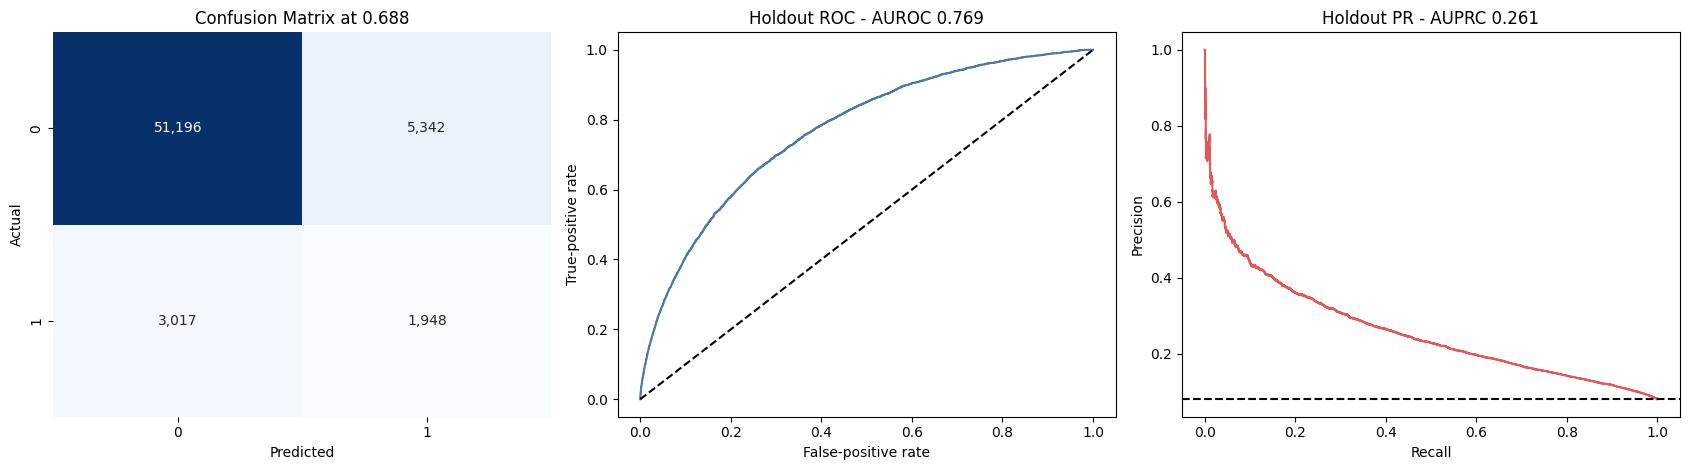

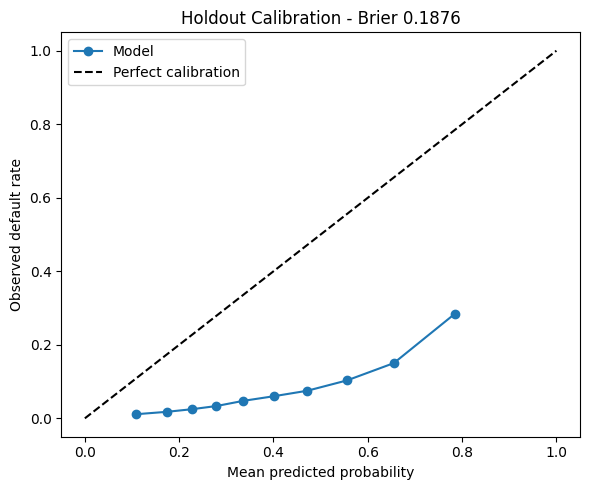

In [29]:
matrix = confusion_matrix(y_holdout, holdout_predictions)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.heatmap(matrix, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Confusion Matrix at {decision_threshold:.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_holdout, holdout_probabilities)
axes[1].plot(fpr, tpr, color="#4C78A8")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[1].set_title(f"Holdout ROC - AUROC {holdout_metrics['AUROC']:.3f}")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")

precision, recall, _ = precision_recall_curve(y_holdout, holdout_probabilities)
axes[2].plot(recall, precision, color="#E45756")
axes[2].axhline(y_holdout.mean(), linestyle="--", color="black")
axes[2].set_title(f"Holdout PR - AUPRC {holdout_metrics['AUPRC']:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

fraction_positive, mean_predicted = calibration_curve(
    y_holdout,
    holdout_probabilities,
    n_bins=10,
    strategy="quantile",
)
plt.figure(figsize=(6, 5))
plt.plot(mean_predicted, fraction_positive, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
plt.title(f"Holdout Calibration - Brier {holdout_metrics['Brier']:.4f}")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.tight_layout()
plt.show()

## Save model and results


In [27]:
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "credit_scoring_feature_pipeline.pkl"
best_model_path = MODEL_DIR / "best_model.pkl"
comparison_path = REPORT_DIR / "model_comparison.csv"
metadata_path = MODEL_DIR / "model_metadata.json"

model_bundle = {
    "pipeline": final_pipeline,
    "decision_threshold": decision_threshold,
    "input_features": X_train_model.columns.tolist(),
    "identifier": "SK_ID_CURR",
    "target": "TARGET",
}
joblib.dump(model_bundle, model_path)
joblib.dump(model_bundle, best_model_path)
comparison.to_csv(comparison_path)
fold_scores.to_csv(REPORT_DIR / "cross_validation_scores.csv", index=False)
cluster_uplift_report.to_csv(REPORT_DIR / "customer_segment_model_uplift.csv", index=False)
governance_report.to_csv(REPORT_DIR / "model_governance_subgroup_audit.csv", index=False)

metadata = {
    "selected_model": selected_model_name,
    "best_parameters": search.best_params_,
    "decision_threshold": decision_threshold,
    "holdout_metrics": holdout_metrics,
    "training_rows": len(X_train_model),
    "holdout_rows": len(X_holdout_model),
    "input_feature_count": X_train_model.shape[1],
    "customer_segment_used": use_customer_segment,
    "random_state": 42,
    "model_drop_features": model_drop_features,
    "cv_AUROC_mean": float(fold_scores["AUROC"].mean()),
    "cv_AUROC_std": float(fold_scores["AUROC"].std(ddof=1)),
}
metadata_path.write_text(json.dumps(metadata, indent=2))

reloaded_bundle = joblib.load(model_path)
sample_probabilities = reloaded_bundle["pipeline"].predict_proba(X_holdout_model.head(5))[:, 1]
assert len(sample_probabilities) == 5
assert np.isfinite(sample_probabilities).all()

print(f"Saved model: {model_path}")
print(f"Saved curriculum model: {best_model_path}")
print(f"Saved comparison: {comparison_path}")
print(f"Saved metadata: {metadata_path}")
print(sample_probabilities)

Saved model: ..\models\credit_scoring_feature_pipeline.pkl
Saved curriculum model: ..\models\best_model.pkl
Saved comparison: ..\reports\model_comparison.csv
Saved metadata: ..\models\model_metadata.json
[0.11164962 0.32101357 0.10494009 0.16714534 0.90982221]
